In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

texts = [
    "I love machine learning",
    "Machine learning is amazing",
    "I hate spam emails",
    "Spam messages are annoying",
    "I enjoy coding in python",
    "I dislike unwanted emails"
]

labels = [1, 1, 0, 0, 1, 0]

vectorizer = CountVectorizer()
X = vectorizer.fit_transform(texts)

X_train, X_test, y_train, y_test = train_test_split(
    X, labels, test_size=0.3, random_state=42
)

model = MultinomialNB()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

new_texts = ["I love python", "spam emails are bad"]
new_X = vectorizer.transform(new_texts)

predictions = model.predict(new_X)

for text, pred in zip(new_texts, predictions):
    print(f'"{text}" ->', "Positive" if pred == 1 else "Negative")

Accuracy: 0.0
"I love python" -> Positive
"spam emails are bad" -> Negative


/tmp/ipykernel_580/2872459315.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data['date'] = pd.to_datetime(data['year'].astype(str) + '-' + data['month'])
/tmp/ipykernel_580/2872459315.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ts_data.rename(columns={'passengers': 'AirPassengers'}, inplace=True)


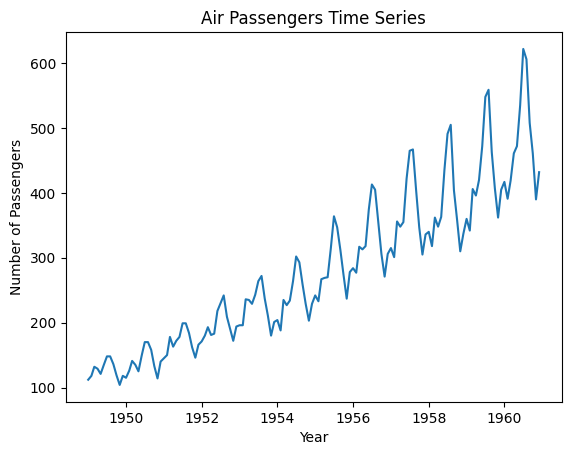

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data = sns.load_dataset("flights")

data['month'] = data['month'].astype(str)
data['date'] = pd.to_datetime(data['year'].astype(str) + '-' + data['month'])

data.set_index('date', inplace=True)

ts_data = data[['passengers']]
ts_data.rename(columns={'passengers': 'AirPassengers'}, inplace=True)

plt.figure()
plt.plot(ts_data)
plt.title("Air Passengers Time Series")
plt.xlabel("Year")
plt.ylabel("Number of Passengers")
plt.show()

/tmp/ipykernel_580/876771513.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data["date"] = pd.to_datetime(data["year"].astype(str) + "-" + data["month"])


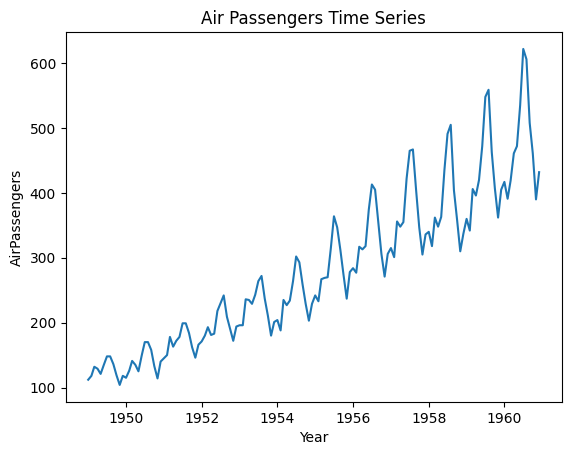

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

data = sns.load_dataset("flights")

data["month"] = data["month"].astype(str)
data["date"] = pd.to_datetime(data["year"].astype(str) + "-" + data["month"])

data.set_index("date", inplace=True)

ts_data = data[["passengers"]]
ts_data.columns = ["AirPassengers"]

plt.figure()
plt.plot(ts_data)
plt.title("Air Passengers Time Series")
plt.xlabel("Year")
plt.ylabel("AirPassengers")
plt.show()

/tmp/ipykernel_580/924130799.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data["date"] = pd.to_datetime(data["year"].astype(str) + "-" + data["month"])


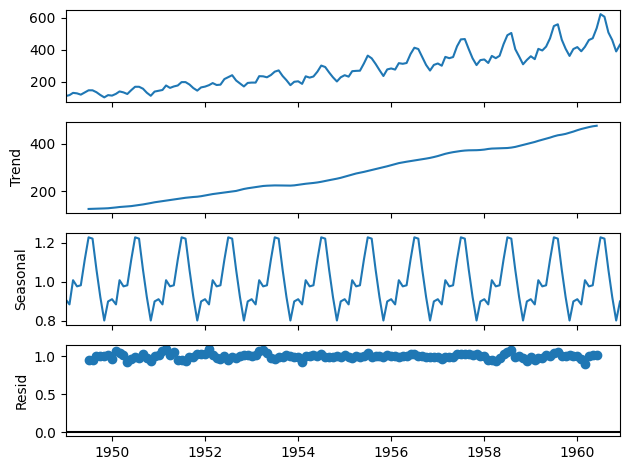

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose

data = sns.load_dataset("flights")

data["month"] = data["month"].astype(str)
data["date"] = pd.to_datetime(data["year"].astype(str) + "-" + data["month"])
data.set_index("date", inplace=True)

ts_data = data[["passengers"]]
ts_data.columns = ["AirPassengers"]

decomposition = seasonal_decompose(ts_data, model="multiplicative", period=12)

decomposition.plot()
plt.show()

/tmp/ipykernel_580/3146262002.py:10: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data["date"] = pd.to_datetime(data["year"].astype(str) + "-" + data["month"])
/tmp/ipykernel_580/3146262002.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ts_data["sin_12"] = np.sin(2 * np.pi * t / 12)


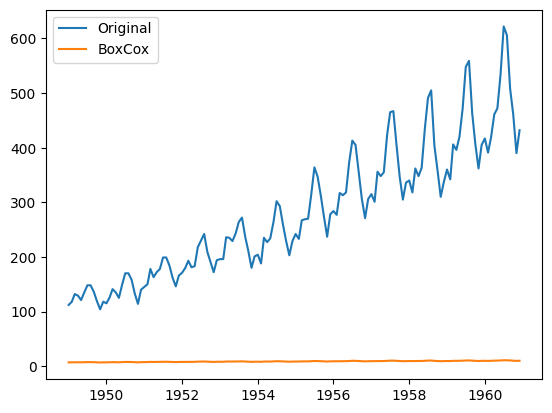

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import boxcox

data = sns.load_dataset("flights")

data["month"] = data["month"].astype(str)
data["date"] = pd.to_datetime(data["year"].astype(str) + "-" + data["month"])
data.set_index("date", inplace=True)

ts_data = data[["passengers"]]
ts_data.columns = ["AirPassengers"]

t = np.arange(len(ts_data))
ts_data["sin_12"] = np.sin(2 * np.pi * t / 12)
ts_data["cos_12"] = np.cos(2 * np.pi * t / 12)

ts_data["BoxCox"], lam = boxcox(ts_data["AirPassengers"])

plt.figure()
plt.plot(ts_data["AirPassengers"], label="Original")
plt.plot(ts_data["BoxCox"], label="BoxCox")
plt.legend()
plt.show()